Loading dataset from: ../data/dataset.jsonl...


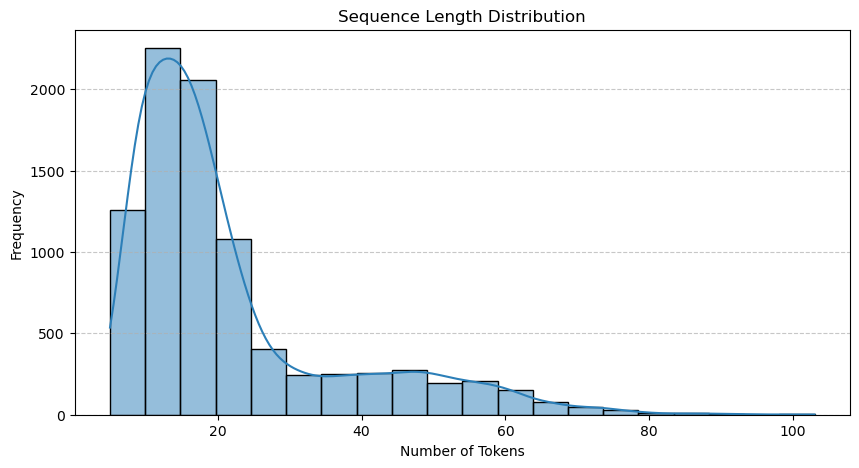

Max sequence length: 103
Mean sequence length: 21.63


/tmp/ipykernel_13558/1479779871.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_entities, y='entity_type', order=df_entities['entity_type'].value_counts().index, palette="viridis")


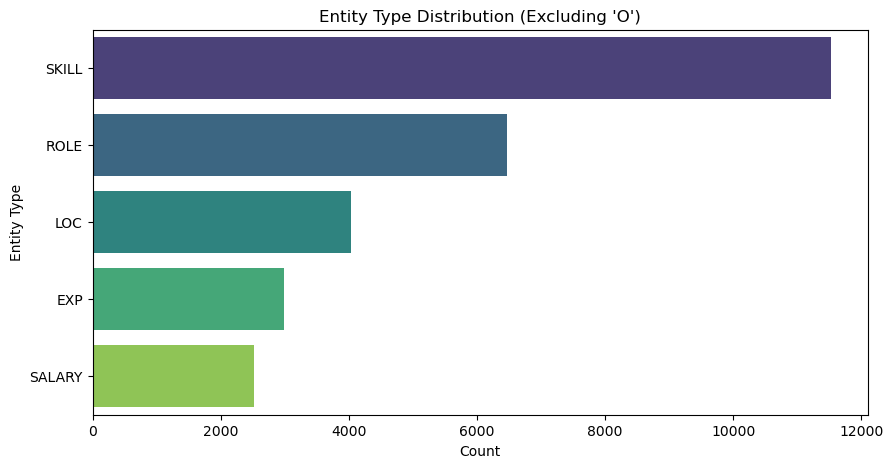

/tmp/ipykernel_13558/1479779871.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_entities, x='length', y='entity_type', palette="Set2")


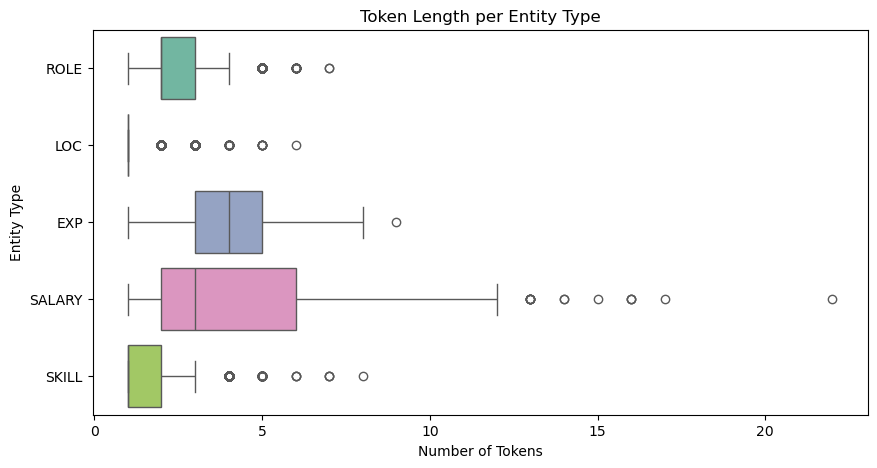


--- DATA QUALITY REPORT ---
Total IOB formatting errors detected: 0
STATUS: IOB format is strictly valid.
---------------------------

Text report saved to ../result/data_report.txt


In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# ==========================================
# CONFIGURATION
# ==========================================
DATASET_PATH = "../data/dataset.jsonl"
# ==========================================

def extract_entities(tags):
    """Extracts entities and their lengths from IOB2 formatted tags."""
    entities = []
    current_entity = None
    length = 0

    for tag in tags:
        if tag.startswith('B-'):
            if current_entity:
                entities.append({'entity_type': current_entity, 'length': length})
            current_entity = tag[2:]
            length = 1
        elif tag.startswith('I-') and current_entity == tag[2:]:
            length += 1
        else:
            if current_entity:
                entities.append({'entity_type': current_entity, 'length': length})
                current_entity = None
                length = 0

    if current_entity:
        entities.append({'entity_type': current_entity, 'length': length})

    return entities

def check_iob_format(tags):
    """Validates IOB format and returns the number of transition errors."""
    errors = 0
    prev_tag = 'O'
    for tag in tags:
        if tag.startswith('I-'):
            entity_type = tag[2:]
            if prev_tag == 'O' or (prev_tag != 'O' and prev_tag[2:] != entity_type):
                errors += 1
        prev_tag = tag
    return errors

def main():
    # 1. Load Data
    if not os.path.exists(DATASET_PATH):
        raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}")

    print(f"Loading dataset from: {DATASET_PATH}...")
    dataset = load_dataset("json", data_files=DATASET_PATH, split="train")
    dataset = dataset.train_test_split(test_size=0.2, seed=42)

    # Convert train split to pandas for EDA
    df_train = dataset["train"].to_pandas()

    # 2. Sequence Length Distribution
    df_train['seq_length'] = df_train['tokens'].apply(len)

    plt.figure(figsize=(10, 5))
    sns.histplot(df_train['seq_length'], bins=20, kde=True, color='#2c7fb8')
    plt.title("Sequence Length Distribution")
    plt.xlabel("Number of Tokens")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig("../result/figures/sequence_length_distribution.png")
    plt.show()

    print(f"Max sequence length: {df_train['seq_length'].max()}")
    print(f"Mean sequence length: {df_train['seq_length'].mean():.2f}")

    # 3. Entity Distribution & Length
    df_train['entities'] = df_train['ner_tags'].apply(extract_entities)
    all_entities = [ent for sublist in df_train['entities'] for ent in sublist]
    df_entities = pd.DataFrame(all_entities)

    if not df_entities.empty:
        # Entity Types
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df_entities, y='entity_type', order=df_entities['entity_type'].value_counts().index, palette="viridis")
        plt.title("Entity Type Distribution (Excluding 'O')")
        plt.xlabel("Count")
        plt.ylabel("Entity Type")
        plt.savefig("../result/figures/entity_types.png")
        plt.show()

        # Entity Lengths
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=df_entities, x='length', y='entity_type', palette="Set2")
        plt.title("Token Length per Entity Type")
        plt.xlabel("Number of Tokens")
        plt.ylabel("Entity Type")
        plt.savefig("../result/figures/entity_lengths.png")
        plt.show()

    # 4. Data Quality Validation
    df_train['iob_errors'] = df_train['ner_tags'].apply(check_iob_format)
    total_errors = df_train['iob_errors'].sum()

    print("\n--- DATA QUALITY REPORT ---")
    print(f"Total IOB formatting errors detected: {total_errors}")
    if total_errors > 0:
        print("WARNING: Labeling inconsistencies found (e.g., 'I-' tag without preceding 'B-' tag).")
    else:
        print("STATUS: IOB format is strictly valid.")
        print("---------------------------\n")

        report = f"""
        Max sequence length: {df_train['seq_length'].max()}
        Mean sequence length: {df_train['seq_length'].mean():.2f}

        --- DATA QUALITY REPORT ---
        Total IOB formatting errors detected: {total_errors}
        """

    if total_errors > 0:
        report += "WARNING: Labeling inconsistencies found (e.g., 'I-' tag without preceding 'B-' tag).\n"
    else:
        report += "STATUS: IOB format is strictly valid.\n"

        report += "---------------------------\n"

    with open("../result/data_report.txt", "w") as f:
        f.write(report)

    print("Text report saved to ../result/data_report.txt")

if __name__ == "__main__":
    main()